# QRT benchmark versus our first model

This notebook compares the Ridge submission benchmark supplied by QRT with our
first Ridge model. Both models are evaluated on the same eight date-grouped
folds, the same rows and the same continuous target. Predictions are converted
to classes with the same threshold: `score > 0`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid")
ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "src").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.cross_validation import CVConfig, ModelConfig, run_cv
from src.data import ChallengeDataLoader
from src.metrics import compare_oof
from src.models import FixedEffectDesign, MODEL_FEATURES

X_train = ChallengeDataLoader.load_X_train()
y_train = ChallengeDataLoader.load_y_train()

## 1. Model definitions

**QRT Ridge benchmark.** The supplied submission notebook uses all 20 return
lags, all 20 signed-volume lags, median daily turnover, rolling row summaries
and date-level averages. Missing values are replaced with zero before fitting
`Ridge(alpha=1)`.

**Our first model.** Our first model uses eight selected return lags, allocation
and group fixed effects, and allocation-specific `RET_1` slopes. Median
imputation, standardisation and encodings are fitted inside the pipeline before
`Ridge(alpha=100)`.

In [2]:
RETURN_FEATURES = tuple(f"RET_{lag}" for lag in range(1, 21))
VOLUME_FEATURES = tuple(f"SIGNED_VOLUME_{lag}" for lag in range(1, 21))
AVERAGE_WINDOWS = (3, 5, 10, 15, 20)
STD_WINDOWS = (20,)
QRT_INPUT_FEATURES = ("TS", *RETURN_FEATURES, *VOLUME_FEATURES, "MEDIAN_DAILY_TURNOVER")


class QRTFeatureBuilder(BaseEstimator, TransformerMixin):
    '''Reproduce the features in the QRT submission benchmark.'''

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        frame = X.copy()
        for window in AVERAGE_WINDOWS:
            feature = f"AVERAGE_PERF_{window}"
            frame[feature] = frame[list(RETURN_FEATURES[:window])].mean(axis=1)
            frame[f"ALLOCATIONS_AVERAGE_PERF_{window}"] = frame.groupby("TS")[
                feature
            ].transform("mean")
        for window in STD_WINDOWS:
            feature = f"STD_PERF_{window}"
            frame[feature] = frame[list(RETURN_FEATURES[:window])].std(axis=1)
            frame[f"ALLOCATIONS_STD_PERF_{window}"] = frame.groupby("TS")[
                feature
            ].transform("mean")

        features = [*RETURN_FEATURES, *VOLUME_FEATURES, "MEDIAN_DAILY_TURNOVER"]
        features += [f"AVERAGE_PERF_{window}" for window in AVERAGE_WINDOWS]
        features += [f"ALLOCATIONS_AVERAGE_PERF_{window}" for window in AVERAGE_WINDOWS]
        features += [f"STD_PERF_{window}" for window in STD_WINDOWS]
        features += [f"ALLOCATIONS_STD_PERF_{window}" for window in STD_WINDOWS]
        return frame[features].fillna(0)


qrt_pipeline = Pipeline(
    [("features", QRTFeatureBuilder()), ("ridge", Ridge(alpha=1.0))]
)
first_model_pipeline = Pipeline(
    [("design", FixedEffectDesign()), ("ridge", Ridge(alpha=100.0, solver="lsqr"))]
)

## 2. Shared validation protocol

The unique `TS` values are shuffled once with `random_state=0` and split into
eight folds. Every row from a given date stays in the same fold. Each complete
pipeline is cloned and refitted from scratch in each fold.

In [3]:
cv_config = CVConfig(n_splits=8, shuffle=True, random_state=0)

qrt_result = run_cv(
    X_train,
    y_train,
    ModelConfig(
        model=qrt_pipeline,
        regression=True,
        features=list(QRT_INPUT_FEATURES),
    ),
    cv_config,
)
first_model_result = run_cv(
    X_train,
    y_train,
    ModelConfig(
        model=first_model_pipeline,
        regression=True,
        features=list(MODEL_FEATURES),
    ),
    cv_config,
)

## 3. Out-of-fold performance

In [4]:
def result_row(label, result):
    date_summary = result.score_summary(grouper="TS")
    return {
        "model": label,
        "OOF accuracy": result.mean_accuracy,
        "date-clustered standard error": date_summary["standard_error"],
        "date-penalized score": date_summary["penalized_score"],
        "prediction positive rate": result.oof_results["prediction"].mean(),
    }


performance = pd.DataFrame(
    [
        result_row("QRT Ridge benchmark", qrt_result),
        result_row("Our first Ridge model", first_model_result),
    ]
).set_index("model")
performance

,OOF accuracy,date-clustered standard error,date-penalized score,prediction positive rate
model,,,,
QRT Ridge benchmark,0.519660,0.001783,0.517877,0.563719
Our first Ridge model,0.524709,0.001734,0.522975,0.551282


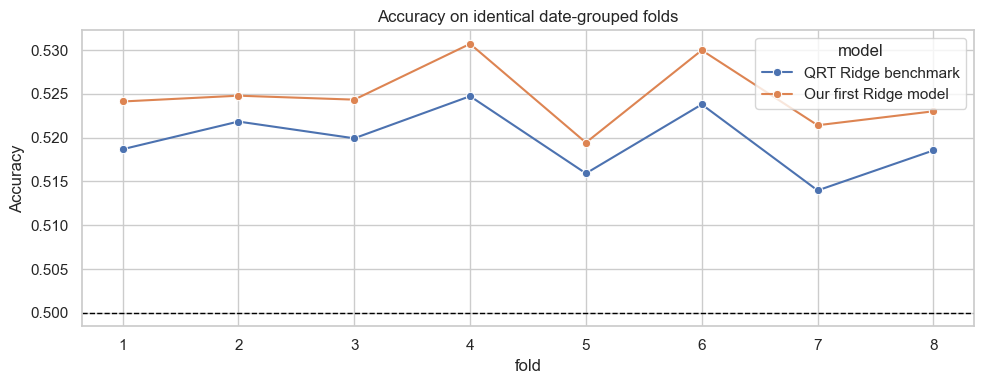

model,Our first Ridge model,QRT Ridge benchmark
fold,,
1,0.524137,0.518682
2,0.524801,0.521847
3,0.524349,0.519932
4,0.530721,0.524743
5,0.519440,0.515924
6,0.529994,0.523804
7,0.521425,0.513978
8,0.523019,0.518550


In [5]:
folds = pd.concat(
    [
        pd.DataFrame(
            {
                "fold": [fold.fold_id for fold in qrt_result.fold_results],
                "accuracy": [fold.valid_metrics["accuracy"] for fold in qrt_result.fold_results],
                "model": "QRT Ridge benchmark",
            }
        ),
        pd.DataFrame(
            {
                "fold": [fold.fold_id for fold in first_model_result.fold_results],
                "accuracy": [fold.valid_metrics["accuracy"] for fold in first_model_result.fold_results],
                "model": "Our first Ridge model",
            }
        ),
    ],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=folds, x="fold", y="accuracy", hue="model", marker="o", ax=ax)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_title("Accuracy on identical date-grouped folds")
ax.set_ylabel("Accuracy")
plt.tight_layout()
plt.show()
folds.pivot(index="fold", columns="model", values="accuracy")

## 4. Paired comparison by date

In [6]:
paired = compare_oof(
    first_model_result.oof_results,
    qrt_result.oof_results,
    group="TS",
)
pd.Series(paired).to_frame("value")

,value
mean_accuracy_gain,0.005049
group_mean_gain,0.005420
group_gain_standard_error,0.000903
ci95_low,0.003278
ci95_high,0.006819
groups_won,1345.000000
groups_tied,125.000000
groups_lost,1052.000000
n_groups,2522.000000


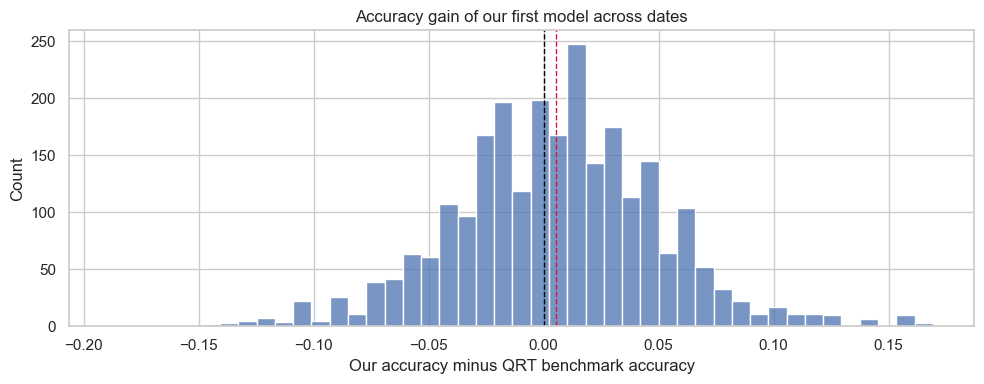

In [7]:
row_gain = (
    first_model_result.oof_results["is_correct"]
    - qrt_result.oof_results["is_correct"]
)
date_gain = row_gain.groupby(first_model_result.oof_results["TS"]).mean()

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(date_gain, bins=45, ax=ax)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.axvline(date_gain.mean(), color="crimson", linestyle="--", linewidth=1)
ax.set_title("Accuracy gain of our first model across dates")
ax.set_xlabel("Our accuracy minus QRT benchmark accuracy")
plt.tight_layout()
plt.show()

In [8]:
gain_pp = 100 * paired["mean_accuracy_gain"]
ci_low_pp = 100 * paired["ci95_low"]
ci_high_pp = 100 * paired["ci95_high"]
display(
    Markdown(
        f'''
## Conclusion

Our first Ridge model improves row-level out-of-fold accuracy by
**{gain_pp:.2f} percentage points** relative to the QRT Ridge benchmark. The
date-clustered 95% interval for the paired gain is **[{ci_low_pp:.2f},
{ci_high_pp:.2f}] percentage points**. It wins on
**{paired['groups_won']:,}** dates, ties on **{paired['groups_tied']:,}**, and
loses on **{paired['groups_lost']:,}**.

The supplied QRT notebook also reports an eight-fold mean accuracy of **52.22%**
for a separate LightGBM benchmark. That result is shown only as contextual
evidence: it is not the primary comparison because it is a different model
family and only its printed aggregate outputs were supplied.
'''
    )
)


## Conclusion

Our first Ridge model improves row-level out-of-fold accuracy by
**0.50 percentage points** relative to the QRT Ridge benchmark. The
date-clustered 95% interval for the paired gain is **[0.33,
0.68] percentage points**. It wins on
**1,345** dates, ties on **125**, and
loses on **1,052**.

The supplied QRT notebook also reports an eight-fold mean accuracy of **52.22%**
for a separate LightGBM benchmark. That result is shown only as contextual
evidence: it is not the primary comparison because it is a different model
family and only its printed aggregate outputs were supplied.
